# Network Science Assignment 7

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 11. November 2024

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import glob
import numpy as np
import random
import tqdm

In [2]:
def initialize_figure(ROWS, COLS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(8 * COLS, 8 * ROWS))
    axes = axes.flatten()
    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

def clean_figure(fig, axes, start, end):
    for i in range(start, end):
        fig.delaxes(axes[i])


In [3]:
# load the data
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1
Generate synthetic networks:
- Random networks (Erdos–Rényi) (with n= 1000 and ⟨k⟩ = {1,4})
- Scale‑free networks (Barabási‑Albert) (with n=1000 and m= {2,4})

In [6]:
n = 1000
# generate erdos renyi
# given k: p = (k/(n-1))
er_graphs = {k: nx.erdos_renyi_graph(n, k/(n-1)) for k in [1,4]}
# generate barabasi_albert
ba_graphs = {k: nx.barabasi_albert_graph(n, k) for k in [2,4]}

## Task 2
Plot the degree distributions of the synthetic networks and of the networks provided in the
datasets

Text(0.5, 0.95, 'Task 2 - Datasets')

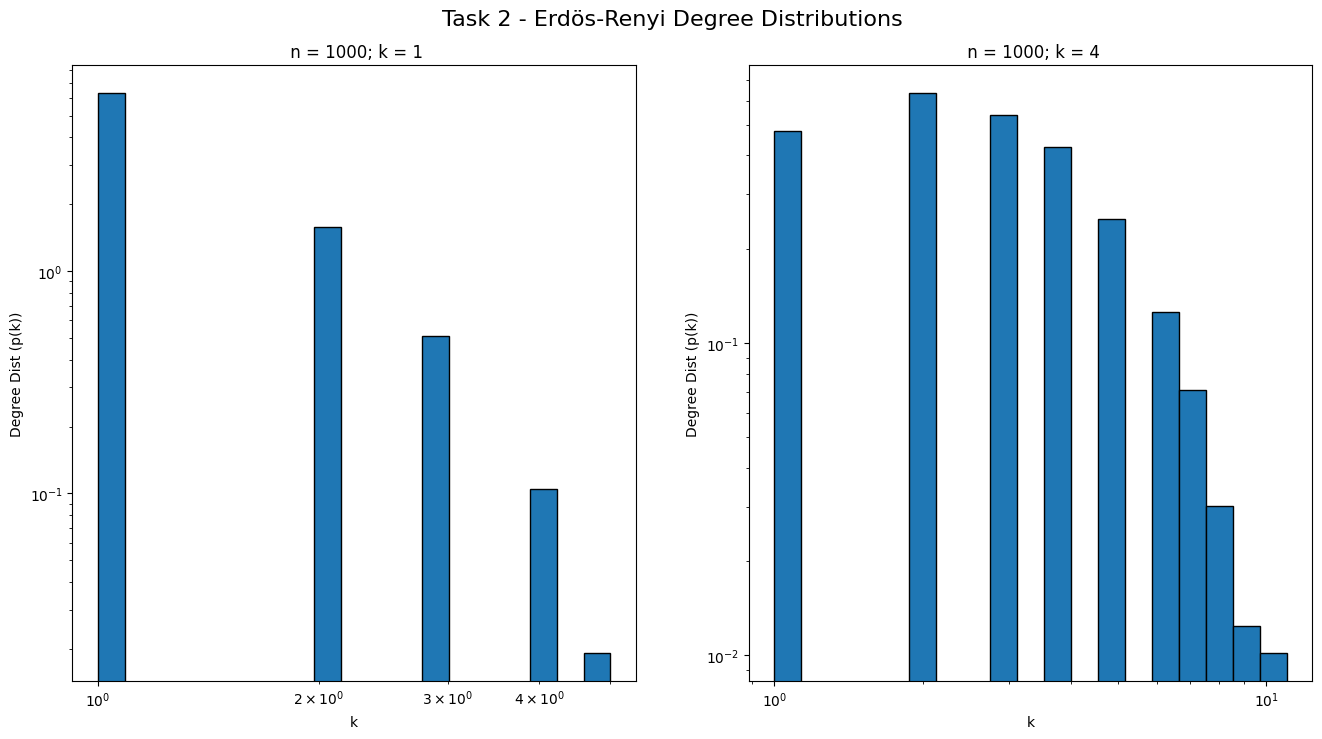

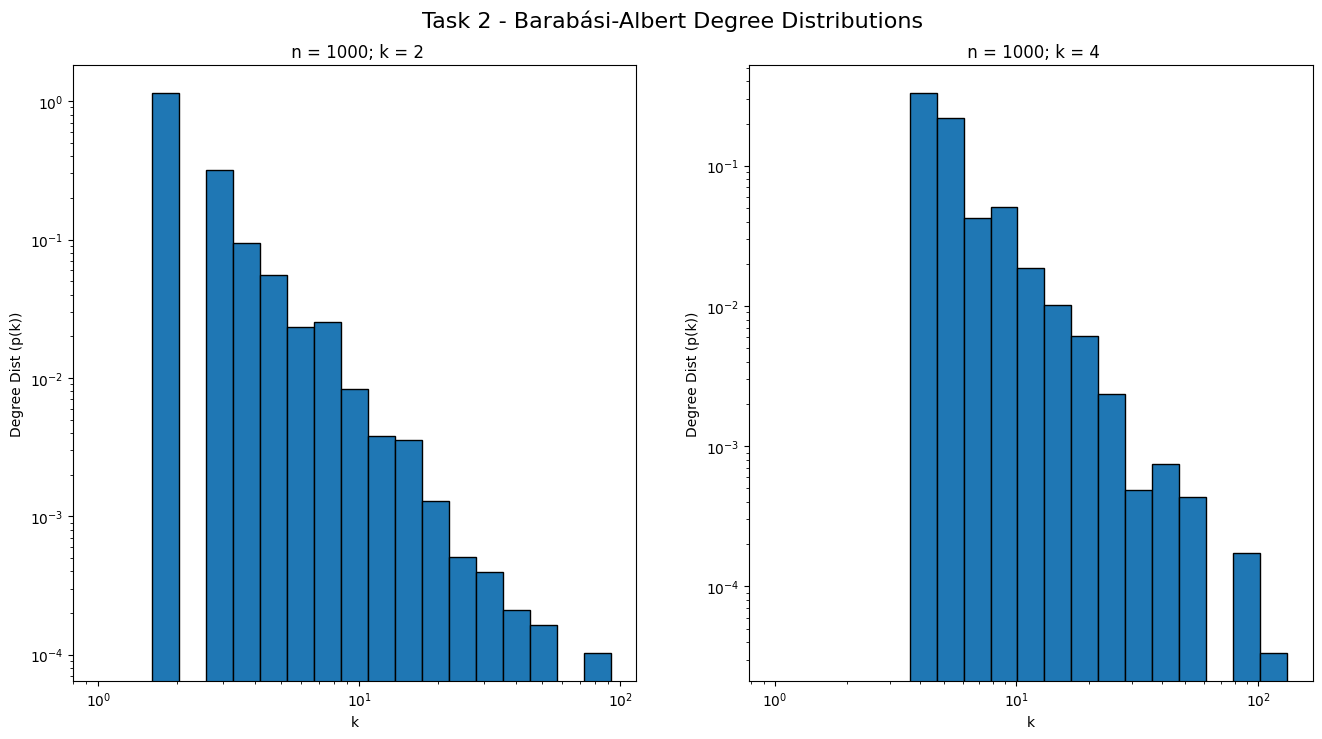

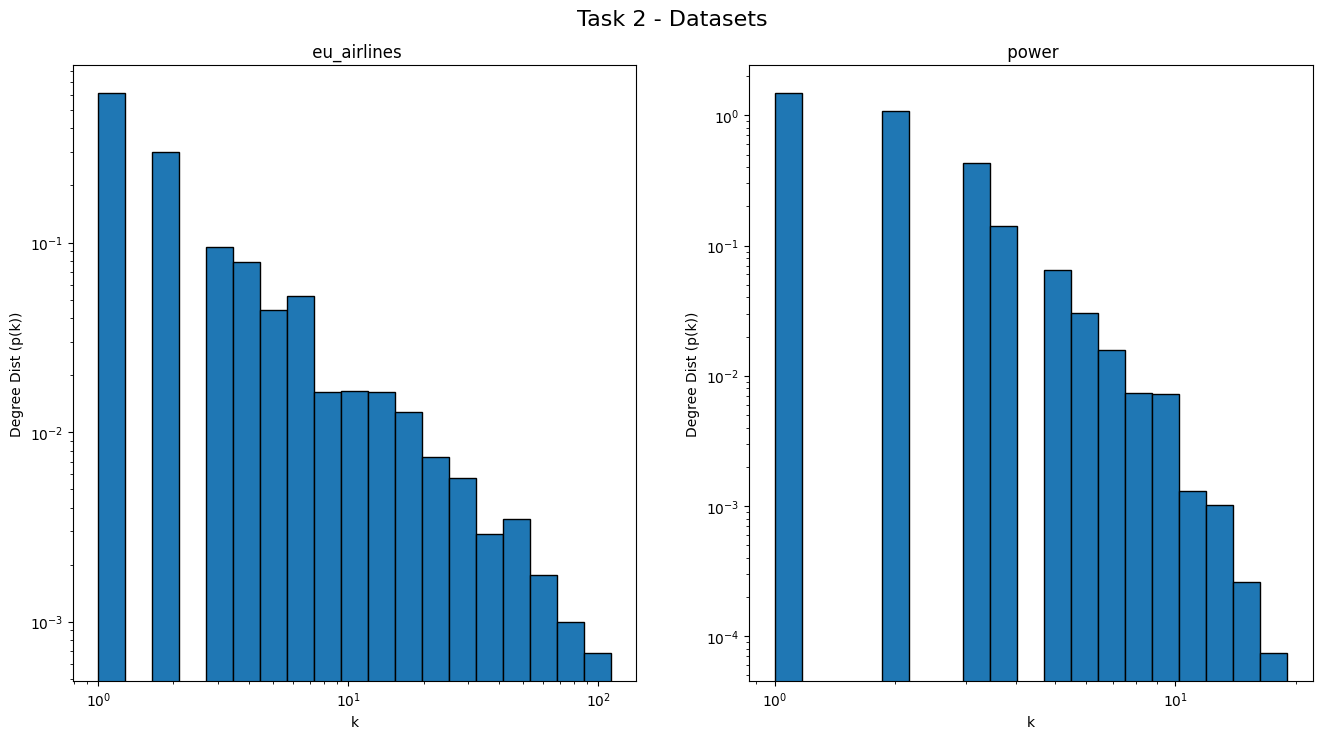

In [7]:
# plots the degree distribution against the degree using logarithmic binning
def plot_degree_dist(g, ax, title=None):
    degrees = list(dict(g.degree()).values())
    bins = np.logspace(np.log10(1), np.log10(max(degrees)), 20)

    ax.hist(degrees, bins=bins, density=True, edgecolor='black') 
    ax.set_xscale('log')
    ax.set_yscale('log')

    set_ax_labels(ax, "k", "Degree Dist (p(k))", f"{title}")

# synthetic data erdos renyi
fig, axes = initialize_figure(1,2)

for i, (k, g) in enumerate(er_graphs.items()):
    plot_degree_dist(g, axes[i], title=f"n = 1000; k = {k}")

fig.suptitle("Task 2 - Erdös-Renyi Degree Distributions", fontsize=16, y=0.95)

# synthetic data barabasi_albert_graph
fig, axes = initialize_figure(1,2)

for i, (k, g) in enumerate(ba_graphs.items()):
    plot_degree_dist(g, axes[i], title=f"n = 1000; k = {k}")

fig.suptitle("Task 2 - Barabási-Albert Degree Distributions", fontsize=16, y=0.95)

clean_figure(fig, axes, len(ba_graphs), len(axes))

# datasets
fig, axes = initialize_figure(1,2)

for i, g in enumerate(data_lst):
    plot_degree_dist(g, axes[i], title=f"{data_names[i]}")

fig.suptitle("Task 2 - Datasets", fontsize=16, y=0.95)

## Task 3
Plot the size of the largest connected component as a function of removed edges and nodes in two scenarios for the synthetic graphs and the real networks in the datasets:
- Random attacks (failures)
- Targeted attacks (degree centrality and betweenness centrality)

In [ ]:
def size_largest_cc(G):
    return len(max(nx.connected_components(G), key=len))

def random_attack_node(g):
    return random.choice(list(g.nodes))

def random_attack_edge(g):
    return random.choice(list(g.edges))

def degree_centrality_attack(g):
    degrees = dict(g.degree())
    return max(degrees, key=degrees.get)

def betweenness_centrality_attack(g):
    betweenness = nx.betweenness_centrality(g)
    return max(betweenness, key=betweenness.get)


def attack(g, attack_function):
    g_copy = g.copy()
    N = g_copy.number_of_nodes()
    p0 = size_largest_cc(g_copy)
    removed_nodes = [(0, 1)]  
    j = 0
    with tqdm(total=N, desc='Attacking nodes', unit='node') as pbar:
        while len(g_copy.nodes) > 0:
            node = attack_function(g_copy)
            g_copy.remove_node(node)
            j += 1
            pbar.update(1) 

            f = j / N
            largest_cc_size = size_largest_cc(g_copy)
            pf_p0 = largest_cc_size / p0
            removed_nodes.append((f, pf_p0))

            if largest_cc_size == 1:
                break
    x = [item[0] for item in removed_nodes]
    y = [item[1] for item in removed_nodes]
    return x, y

def attack_edges(g, attack_function):
    g_copy = g.copy()
    N = g_copy.number_of_edges()
    p0 = size_largest_cc(g_copy)
    removed_edges = [(0, 1)] 
    j = 0
    while g_copy.number_of_edges() > 0:
        edge = attack_function(g_copy)
        g_copy.remove_edge(*edge)
        j += 1
        f = j / N
        largest_cc_size = size_largest_cc(g_copy)
        pf_p0 = largest_cc_size / p0
        removed_edges.append((f, pf_p0))
        if largest_cc_size == 1:
            break
    x = [item[0] for item in removed_edges]
    y = [item[1] for item in removed_edges]
    return x, y


attack_strategies = [
    ('Random Node Removal', random_attack_node, 'Blues', 'node'),
    ('Random Edge Removal', random_attack_edge, 'Purples', 'edge'),
    ('Degree Centrality Attacks', degree_centrality_attack, 'Reds', 'node'),
    ('Betweenness Centrality Attacks', betweenness_centrality_attack, 'Greens', 'node'),
]

Random Node Removal
Graph k=1
Graph k=4
Random Edge Removal
Graph k=1
Graph k=4
Degree Centrality Attacks
Graph k=1
Graph k=4
Betweenness Centrality Attacks
Graph k=1
Graph k=4


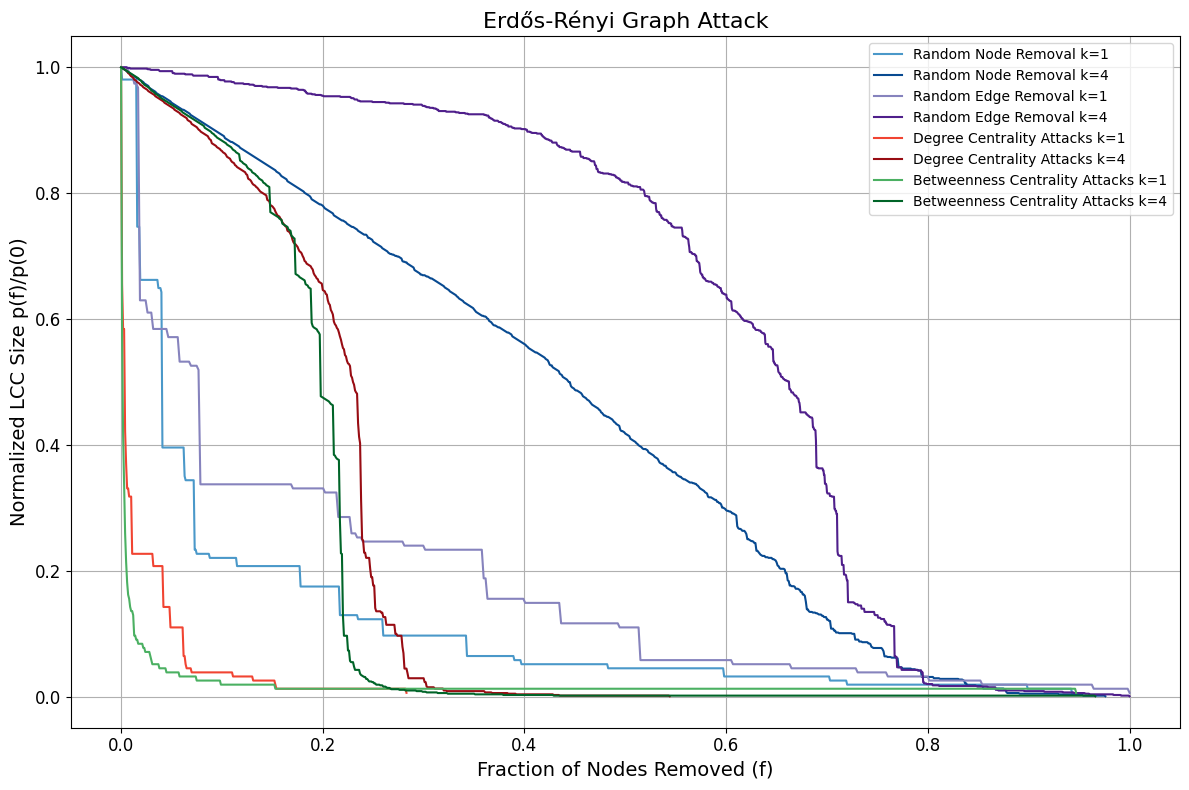

In [14]:
plt.figure(figsize=(12, 8))

for strategy_name, attack_function, cmap_name, type in attack_strategies:
    print(f"{strategy_name}")
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(ci) for ci in [0.6, 0.9]]
    
    for i, (k, g) in enumerate(er_graphs.items()):
        print(f"Graph k={k}")
        if type == 'node':
            x, y = attack(g, attack_function)
        else: 
            x, y = attack_edges(g, attack_function)
        plt.plot(x, y, color=colors[i], label=f'{strategy_name} k={k}')

plt.legend(fontsize=10, loc='best')
plt.xlabel('Fraction of Nodes Removed (f)', fontsize=14)
plt.ylabel('Normalized LCC Size p(f)/p(0)', fontsize=14)
plt.title('Erdős-Rényi Graph Attack', fontsize=16)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Random Node Removal
Graph m=2
Graph m=4
Random Edge Removal
Graph m=2
Graph m=4
Degree Centrality Attacks
Graph m=2
Graph m=4
Betweenness Centrality Attacks
Graph m=2
Graph m=4


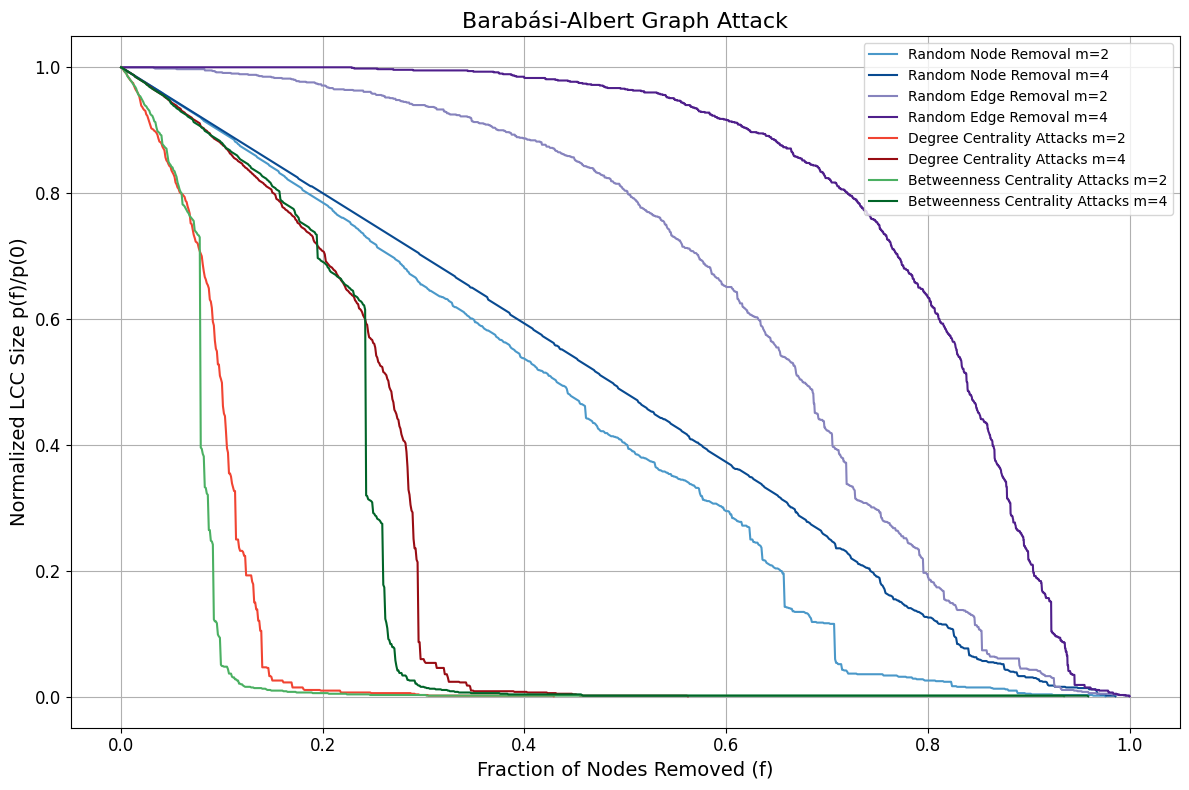

In [15]:
# Initialize the figure
plt.figure(figsize=(12, 8))

for strategy_name, attack_function, cmap_name, attack_type in attack_strategies:
    print(f"{strategy_name}")
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(ci) for ci in [0.6, 0.9]]
    
    for i, (m, g) in enumerate(ba_graphs.items()):
        print(f"Graph m={m}")
        if attack_type == 'node':
            x, y = attack(g, attack_function)
        else:
            x, y = attack_edges(g, attack_function)
        plt.plot(x, y, color=colors[i], label=f'{strategy_name} m={m}')

plt.legend(fontsize=10, loc='best')
plt.xlabel('Fraction of Nodes Removed (f)', fontsize=14)
plt.ylabel('Normalized LCC Size p(f)/p(0)', fontsize=14)
plt.title('Barabási-Albert Graph Attack', fontsize=16)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


Random Node Removal
417
Graph eu_airlines
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266


KeyboardInterrupt: 

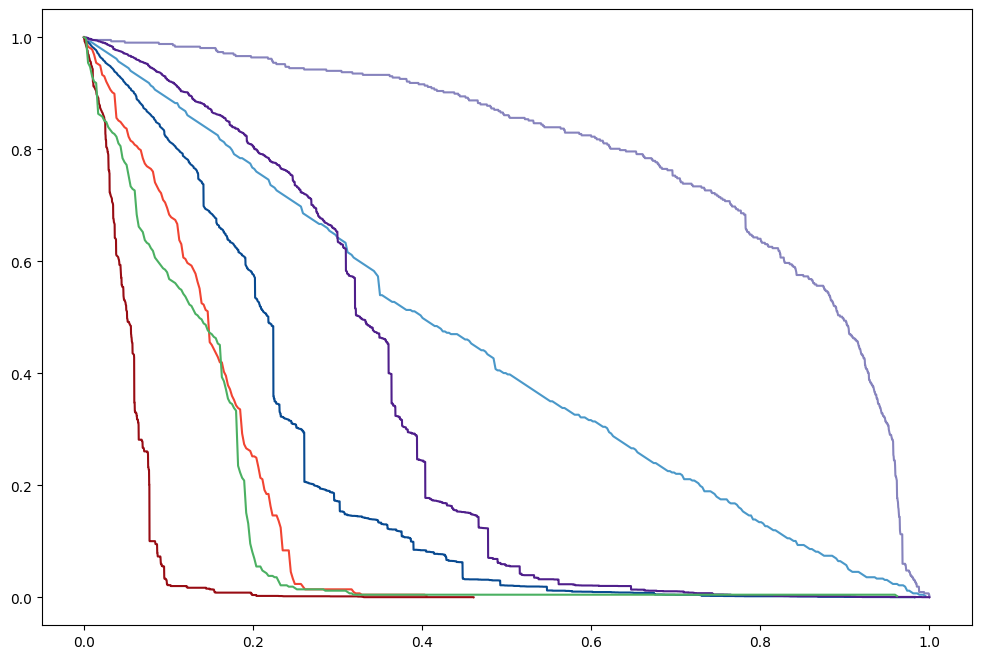

In [ ]:
# Initialize the figure
plt.figure(figsize=(12, 8))

for strategy_name, attack_function, cmap_name, attack_type in attack_strategies:
    print(f"{strategy_name}")
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(ci) for ci in [0.6, 0.9]]
    
    for i, g in enumerate(data_lst):
        print(f"Graph {data_names[i]}")
        if attack_type == 'node':
            x, y = attack(g, attack_function)
        else:
            x, y = attack_edges(g, attack_function)        
        
        plt.plot(x, y, color=colors[i],
                 label=f'{strategy_name} {data_names[i]}')

plt.legend(fontsize=6)

plt.xlabel('Nodes Removed', fontsize=14)
plt.ylabel('Size of LCC', fontsize=14)
plt.title('Data-Sets', fontsize=16)

plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
